# Google Colab Setup

In [ ]:
# #@title << Setup Google Colab by running this cell {display-mode: "form"}
# import sys
# if 'google.colab' in sys.modules:
#     # Clone GitHub repository
#     !git clone https://github.com/epfl-exts/amld20-text-classification.git
        
#     # Copy files required to run the code
#     !cp -r "amld20-text-classification/data" "amld20-text-classification/tools.py" .
    
#     # Install packages via pip
#     !pip install -r "amld20-text-classification/colab-requirements.txt"
    
#     # Restart Runtime
#     import os
#     os.kill(os.getpid(), 9)

# Time series analysis :: Energy Forecasting

## Task 

We want to develop a model to predict the one hour ahead electricity load based on the hourly electricity load and temperature data.

## Data

We use the data from the [Global Energy Forecasting Competition](https://en.wikipedia.org/wiki/Global_Energy_Forecasting_Competition). We focus on the data for the year 2014 which contains 8'760 observations. The dataset has been downloaded for you and is available in the *data* folder.

__Notebook overview__:

- Loading the data
- Preliminary EDA
- Creating time features
- Creating lags
- Splitting the sample
- Loading the train/test sets
- Creating a dummy baseline
- Performing the data preprocessing
- Creating the parameter grid and the pipeline
- Creating the cross-validation object: splitting the training set into training and validation sets
- Fitting and prediction
- Post-modeling analysis and improving the basleine

In [2]:
# Load settings and functions

%run tools.py

In [3]:
df = load_data()

Data loaded.
Data size: (8760, 2)


Let's have a close look at the dataset.

In [4]:
info_data(df)

Frequency of observations:  H
---------------------------------------
Number of days:  365
Number of month:  12
---------------------------------------
First month:  January
Last month:  December
---------------------------------------
Available variables:  ['electric load', 'temperature']
variable types: [dtype('float64'), dtype('float64')]
---------------------------------------
Number of missing hours:  [0, 0]


Let's have a look at a few rows from the dataset.

In [5]:
df.head(5)

,electric load,temperature
timestamp,,
2014-01-01 00:00:00,3295.0,-12.592593
2014-01-01 01:00:00,3173.0,-11.851852
2014-01-01 02:00:00,3085.0,-12.777778
2014-01-01 03:00:00,3053.0,-12.777778
2014-01-01 04:00:00,3077.0,-13.333333


## Explore the data

Now, let's visualise the electric loads and the temperature

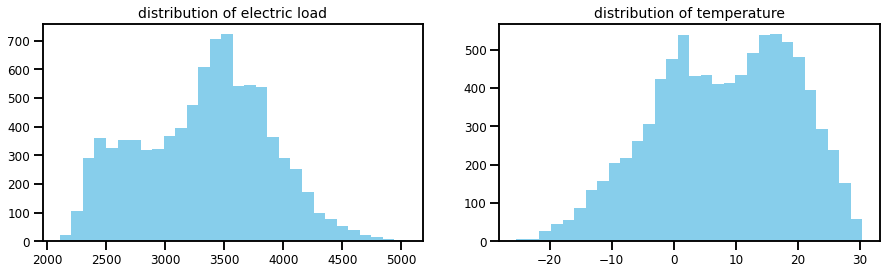

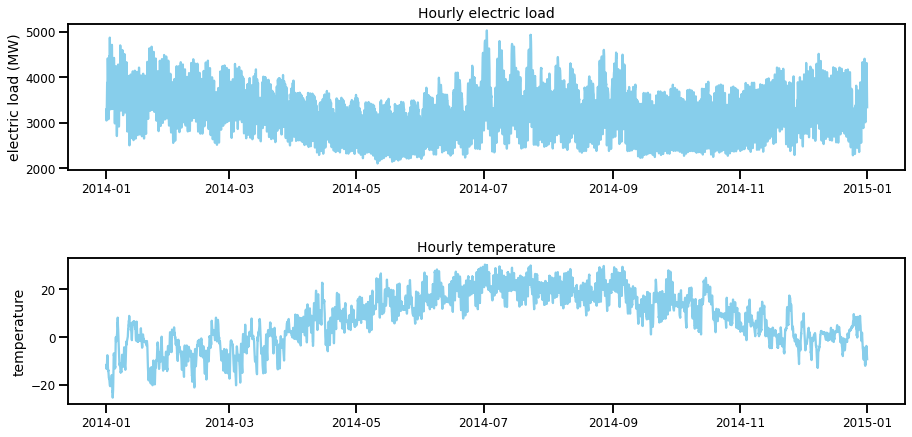

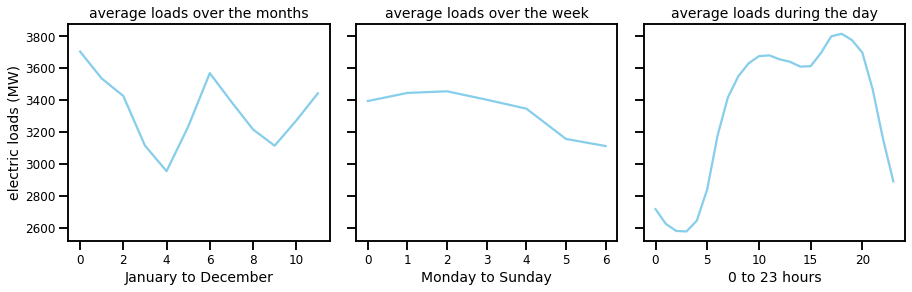

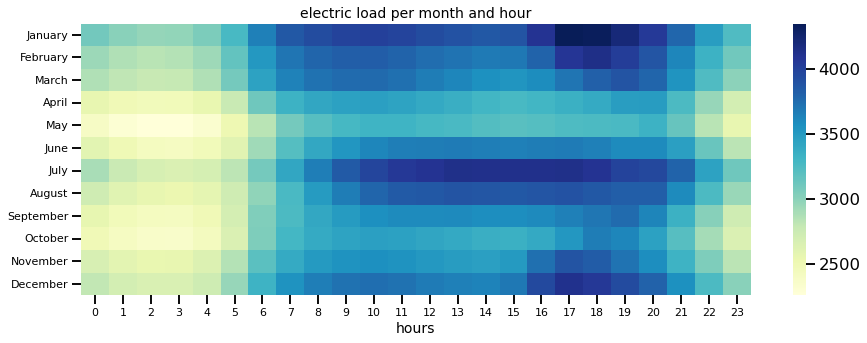

In [18]:
plot_data()

## Correlation analysis

Since the objective to predict the loads using past load and temperature values, we should check the correlations and auto-correlations.

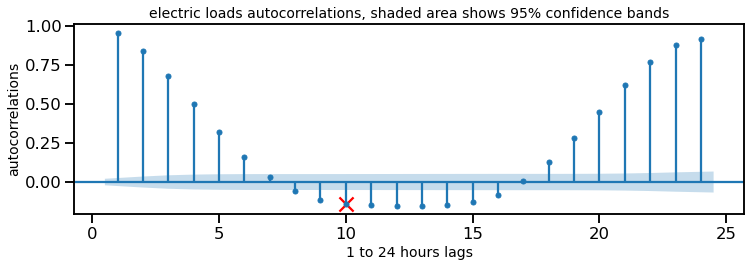

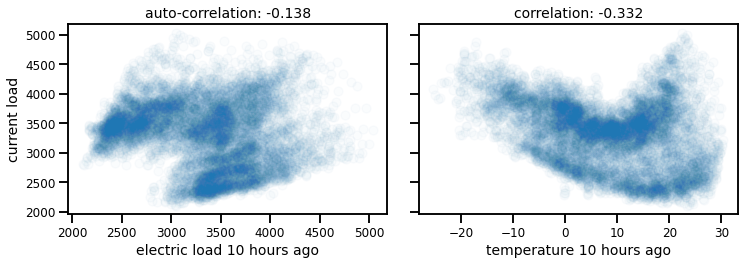

In [8]:
plot_corr(n_lags=10) # n_lag is between 1 and 24

## Split data

Train data from 2014-Jan to 2014-Nov (8015, 6)
Test data 2014-Dec (744, 6)


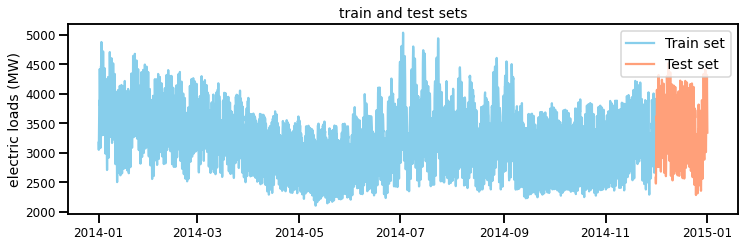

In [9]:
# Train/test splitting
train, test = sample_split()

## Training

Preprocessing data is done!
Cross-validation is setup!
Grid search is setup!
Training with grid search and cross-validation is done!
A total of 100 models are fitted


Here is the results of grid search:




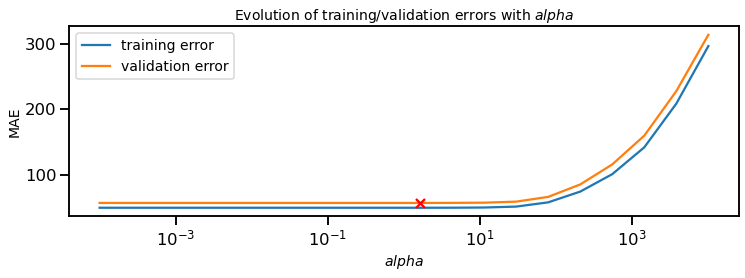

In [10]:
# Fit a linear regression or a random forest model on the train data
model = train_model(train, select_model='regression') 
# select_model = 'regression' or 'randomforest'

## Prediction and evaluation

baseline MAE: 455.40
smart baseline MAE: 131.28
linear regression MAE: 52.49




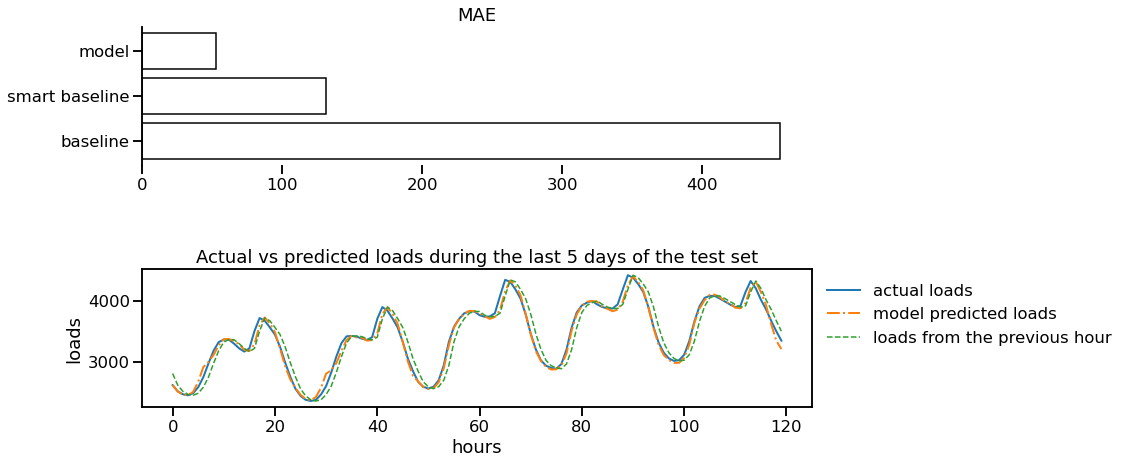

In [11]:
evaluate_model(model, train, test, n_days=5) # n_days is between 1 and 31